# Byte-Pair Encoding (BPE) Tokenizer

## Problem (unicode1): Understanding Unicode (1 point)

(a) What Unicode character does chr(0) return?

Answer: '\x00'

In [1]:
chr(0)

: 

(b) How does this character’s string representation (__repr__()) differ from its printed representation?

Answer: the string representation contains an extra backslash.

In [32]:
chr(0).__repr__()

"'\\x00'"

(c) What happens when this character occurs in text?

Answer: it disappears in printed version since it is a null character.

In [33]:
chr(0)

'\x00'

In [34]:
print(chr(0))

 


In [35]:
"this is a test" + chr(0) + "string"

'this is a test\x00string'

In [36]:
print("this is a test" + chr(0) + "string")

this is a test string


## Problem (unicode2): Unicode Encodings

(a) What are some reasons to prefer training our tokenizer on UTF-8 encoded bytes, rather than UTF-16 or UTF-32? It may be helpful to compare the output of these encodings for various input strings.

Answer: UTF-8 is mostly used currently.

(b) Consider the following (incorrect) function, which is intended to decode a UTF-8 byte string into a Unicode string. Why is this function incorrect? Provide an example of an input byte string that yields incorrect results.

```python
def decode_utf8_bytes_to_str_wrong(bytestring: bytes):
    return "".join([bytes([b]).decode("utf-8") for b in bytestring])
```

Answer: `decode_utf8_bytes_to_str_wrong('\x0')`

In [37]:
def decode_utf8_bytes_to_str_wrong(bytestring: bytes):
    return "".join([bytes([b]).decode("utf-8") for b in bytestring])

decode_utf8_bytes_to_str_wrong('\x0')

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 0-2: truncated \xXX escape (1648204821.py, line 4)

(c) Give a two byte sequence that does not decode to any Unicode character(s).

Answer: ['\xe6', '\x88']

In [ ]:
b'\xe6'.decode()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe6 in position 0: unexpected end of data

In [ ]:
b'\x88'.decode()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x88 in position 0: invalid start byte

## Problem (train_bpe_tinystories): BPE Training on TinyStories

(a) Train a byte-level BPE tokenizer on the TinyStories dataset, using a maximum vocabulary size of 10,000. Make sure to add the TinyStories <|endoftext|> special token to the vocabulary. Serialize the resulting vocabulary and merges to disk for further inspection. How many hours and memory did training take? What is the longest token in the vocabulary? Does it make sense?

**Resource requirements**: ≤ 30 minutes (no GPUs), ≤ 30GB RAM

**Hint** You should be able to get under 2 minutes for BPE training using multiprocessing during pretokenization and the following two facts:
-  The <|endoftext|> token delimits documents in the data files.
-  The <|endoftext|> token is handled as a special case before the BPE merges are applied.

**Deliverable**: A one-to-two sentence response.

Answer: memory usage: 460M, time: 543.038s. The longest token is " responsibility", it makes sense.


In [6]:
import pstats

# Load the stats file
p = pstats.Stats('../data/TinyStories/TinyStories.prof')

# Sort by cumulative time and print the top 20 functions
p.sort_stats('cumulative').print_stats(20)

Fri Dec 26 17:57:39 2025    ../data/TinyStories/TinyStories.prof

         383555346 function calls (383554166 primitive calls) in 543.301 seconds

   Ordered by: cumulative time
   List reduced from 710 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  543.301  543.301 /mnt/petrelfs/maosong/miniconda3/envs/cs336/lib/python3.11/site-packages/memory_profiler.py:1185(wrapper)
        1    0.003    0.003  543.040  543.040 /mnt/petrelfs/maosong/miniconda3/envs/cs336/lib/python3.11/site-packages/memory_profiler.py:759(f)
        1    0.944    0.944  543.038  543.038 /mnt/petrelfs/maosong/cs336/assignment1-basics/cs336_basics/tokenizer/train_bpe.py:188(main)
        1    0.084    0.084  531.927  531.927 /mnt/petrelfs/maosong/cs336/assignment1-basics/cs336_basics/tokenizer/train_bpe.py:115(train_bpe)
    10236  153.394    0.015  401.642    0.039 {built-in method builtins.max}
369218707  248.248    0.000  248.248

In [8]:
with open("../data/TinyStories/memory_usage.txt") as f:
    memory_usage = f.read()

print(memory_usage)

Line #    Mem usage    Increment  Occurrences   Line Contents
   188     50.1 MiB     50.1 MiB           1   @profile
   189                                         def main():
   190     50.1 MiB      0.0 MiB           1       parser = ArgumentParser()
   191     50.4 MiB      0.2 MiB           1       parser.add_argument("-i", "--input_path")
   192     50.4 MiB      0.0 MiB           1       parser.add_argument("-v", "--vocab_size", type=int)
   193     50.4 MiB      0.0 MiB           1       parser.add_argument("-o", "--output_dir")
   194     50.4 MiB      0.0 MiB           1       args = parser.parse_args()
   195     50.4 MiB      0.0 MiB           1       logger.add(f"{args.output_dir}/output.log", mode="w")
   196                                         
   197                                             # 5. Save the output
   198     50.4 MiB      0.0 MiB           1       if not os.path.exists(args.output_dir):
   199                                                 os.maked

In [36]:
from tokenizers import Tokenizer

tinystory_tokenizer = Tokenizer.from_file("tokenizer/TinyStories/tokenizer.json")

tinystory_vocab = tinystory_tokenizer.get_vocab()
longest_token = max(tinystory_vocab.keys(), key=len)

print("Longest token:", repr(longest_token))
print("Length:", len(longest_token))

Longest token: 'Ġdisappointment'
Length: 15


(b) Profile your code. What part of the tokenizer training process takes the most time?

**Deliverable**: A one-to-two sentence response.

Answer: the built-in max function takes the most time, in a ratio of 73.9%.

## Problem (train_bpe_expts_owt): BPE Training on OpenWebText

(a) Train a byte-level BPE tokenizer on the OpenWebText dataset, using a maximum vocabulary
size of 32,000. Serialize the resulting vocabulary and merges to disk for further inspection. What
is the longest token in the vocabulary? Does it make sense?

**Resource requirements**: ≤ 12 hours (no GPUs), ≤ 100GB RAM

**Deliverable**: A one-to-two sentence response. Training took around 6 hours.

Answer: the longest token is "----------------------------------------------------------------", it does not make sense.

In [39]:
from tokenizers import Tokenizer

owt_tokenizer = Tokenizer.from_file("tokenizer/OWT/tokenizer.json")

owt_vocab = owt_tokenizer.get_vocab()
longest_token = max(owt_vocab.keys(), key=len)

print("Longest token:", longest_token)
print("Length:", len(longest_token))

Longest token: ----------------------------------------------------------------
Length: 64


(b) Compare and contrast the tokenizer that you get training on TinyStories versus OpenWebText.

**Deliverable**: A one-to-two sentence response.

Answer: there are 7139 tokens are shared by two tokenizers.

In [40]:
set_tinystory = set(tinystory_vocab.keys())
set_owt = set(owt_vocab.keys())

print("Vocab A:", len(set_tinystory))
print("Vocab B:", len(set_owt))
print("Intersection:", len(set_tinystory & set_owt))
print("Only A:", len(set_tinystory - set_owt))
print("Only B:", len(set_owt - set_tinystory))

Vocab A: 10000
Vocab B: 32000
Intersection: 7319
Only A: 2681
Only B: 24681


## Problem (tokenizer_experiments): Experiments with tokenizers

(a) Sample 10 documents from TinyStories and OpenWebText. Using your previously-trained TinyStories and OpenWebText tokenizers (10K and 32K vocabulary size, respectively), encode these sampled documents into integer IDs. What is each tokenizer’s compression ratio (bytes/token)?

**Deliverable**: A one-to-two sentence response.


Answer: OWT Bytes per token: 4.182377049180328; TinyStories bytes per token: 3.3066018631024705

In [44]:
import random

def sample_docs(path, k=10, seed=42, line_len=50):
    random.seed(seed)
    with open(path, "r", encoding="utf-8") as f:
        docs = f.readlines()

    results = []
    while len(results) < k:
        results.extend([x for x in random.sample(docs, k) if len(x) > line_len])
    return results

def compression_ratio(tokenizer, texts, by="byte"):
    total_units = 0
    total_tokens = 0

    for t in texts:
        enc = tokenizer.encode(t)
        total_tokens += len(enc.ids)

        if by == "char":
            total_units += len(t)
        elif by == "byte":
            total_units += len(t.encode("utf-8"))
        else:
            raise ValueError("by must be 'char' or 'byte'")

    return total_units, total_tokens, total_units / total_tokens

owt_samples = sample_docs("data/OpenWebText/owt_train.txt", 10)
tinystory_samples = sample_docs("data/TinyStories/TinyStoriesV2-GPT4-train.txt", 10)

samples = owt_samples + tinystory_samples

owt_total_units, owt_total_tokens, owt_ratio = compression_ratio(owt_tokenizer, samples, by="byte")
print("OWT Bytes per token:", owt_ratio)

tinystory_total_units, tinystory_total_tokens, tinystory_ratio = compression_ratio(tinystory_tokenizer, samples, by="byte")
print("TinyStories bytes per token:", tinystory_ratio)


OWT Bytes per token: 4.182377049180328
TinyStories bytes per token: 3.3066018631024705


(b) What happens if you tokenize your OpenWebText sample with the TinyStories tokenizer? Compare the compression ratio and/or qualitatively describe what happens.

**Deliverable**: A one-to-two sentence response.

Answer: the TinyStories tokenizer produces a longer token ids.

In [46]:
owt_total_units, owt_total_tokens, owt_ratio = compression_ratio(owt_tokenizer, owt_samples, by="byte")
tinystory_total_units, tinystory_total_tokens, tinystory_ratio = compression_ratio(tinystory_tokenizer, owt_samples, by="byte")

print(f"length of tinystories token ids: {tinystory_total_tokens}")
print(f"length of owt token ids: {owt_total_tokens}")

length of tinystories token ids: 1737
length of owt token ids: 1201


(c) Estimate the throughput of your tokenizer (e.g., in bytes/second). How long would it take to tokenize the Pile dataset (825GB of text)?

**Deliverable**: A one-to-two sentence response.

Answer: it takes around 122 hours to process Pile dataset.

In [47]:
texts = "".join(samples)
len(texts.encode("utf-8"))

8164

In [48]:
%%timeit
owt_tokenizer.encode(texts)

4.38 ms ± 251 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [50]:
pile_ms = 825 * 10**9 / 8164 * 4.38
pile_time = pile_ms / 1000 / 60 / 60
print(f"it takes {pile_time} hours to tokenize Pile dataset with OWT tokenizer")

it takes 122.94830965213131 hours to tokenize Pile dataset with OWT tokenizer


(d) Using your TinyStories and OpenWebText tokenizers, encode the respective training and development datasets into a sequence of integer token IDs. We’ll use this later to train our language model. We recommend serializing the token IDs as a NumPy array of datatype uint16. Why is uint16 an appropriate choice?

**Deliverable**: A one-to-two sentence response.

# Transformer

## Problem (transformer_accounting): Transformer LM resource accounting

(a) Consider GPT-2 XL, which has the following configuration:

| field | value|
| --- | --- |
|vocab_size | 50,257|
|context_length | 1,024|
|num_layers | 48|
|d_model | 1,600|
|num_heads | 25|
|d_ff | 6,400|

Suppose we constructed our model using this configuration. How many trainable parameters would our model have? Assuming each parameter is represented using single-precision floating point, how much memory is required to just load this model?

**Deliverable**: A one-to-two sentence response.

Answer: 2.12 B

In [36]:
def compute_params(vocab_size, context_length, num_layers, d_model, num_heads, d_ff):
    # compute params of a transformer model with SwiGLU FFN, RoPE, RMSNorm, MHA
    embedding = vocab_size * d_model
    pre_norm = d_model
    attention = 4 * d_model * d_model 
    ffn = 3 * d_ff * d_model
    post_norm = d_model
    lm_head_norm = d_model
    lm_head = vocab_size * d_model
    
    return embedding + num_layers * (pre_norm + attention + post_norm + ffn) + lm_head_norm + lm_head


print(f"parameters of GPT2-XL: {compute_params(50257, 1024, 48, 1600, 25, 6400) / 10**9} B")

parameters of GPT2-XL: 2.1270576 B


(b) Identify the matrix multiplies required to complete a forward pass of our GPT-2 XL-shaped model. How many FLOPs do these matrix multiplies require in total? Assume that our input sequence has context_length tokens.

**Deliverable**: A list of matrix multiplies (with descriptions), and the total number of FLOPs required.

Answer:

matrix multiplies:
1. attention: Q, K, V, output projection, product of Q and K, product of softmax and V
2. FFN: three linear layers
3. lm_head: linear layers

total FLOPs (we assume the FLOPs of the product between matrix $A$ of size $m\times n$ and a matrix of size $n\times p$ is $mnp$.): 2.256668e+12 FLOPs.

In [51]:
def compute_flops(vocab_size, context_length, num_layers, d_model, num_heads, d_ff):
    attention = 4 * context_length * d_model * d_model + 2 * context_length * context_length * d_model
    ffn = 3 * d_ff * d_model * context_length
    lm_head = d_model * vocab_size * context_length

    return attention * num_layers, ffn * num_layers, lm_head

attention_flops, ffn_flops, lm_head_flops = compute_flops(50257, 1024, 48, 1600, 25, 6400)
total_flops = attention_flops + ffn_flops + lm_head_flops
print(f"FLOPs of GPT2-XL: {total_flops:e} FLOPs")

FLOPs of GPT2-XL: 2.256668e+12 FLOPs


(c) Based on your analysis above, which parts of the model require the most FLOPs?

**Deliverable**: A one-to-two sentence response.

Answer: the FFN requires the most FLOPs, accounts for $67\%$ of total FLOPs

In [52]:
print(f"attention flops ratio: {attention_flops / total_flops:.2%}")
print(f"ffn flops ratio: {ffn_flops / total_flops:.2%}")
print(f"lm_head flops ratio: {lm_head_flops / total_flops:.2%}")

attention flops ratio: 29.44%
ffn flops ratio: 66.91%
lm_head flops ratio: 3.65%


(d) Repeat your analysis with GPT-2 small (12 layers, 768 d_model, 12 heads), GPT-2 medium (24 layers, 1024 d_model, 16 heads), and GPT-2 large (36 layers, 1280 d_model, 20 heads). As the model size increases, which parts of the Transformer LM take up proportionally more or less of the total FLOPs?

**Deliverable**: For each model, provide a breakdown of model components and its associated FLOPs (as a proportion of the total FLOPs required for a forward pass). In addition, provide a one-to-two sentence description of how varying the model size changes the proportional FLOPs of each component.

Answer: the table is shown as follows, the ratio of attention is increasing while the lm_head part is decreasing.

In [59]:
1280*4

5120

In [60]:
# assume d_ff = 4 d_model following GPT-2 XL
flops_result = {
    "GPT-2 small": compute_flops(50257, 1024, 12, 768, 12, 3072),
    "GPT-2 medium": compute_flops(50257, 1024, 24, 1024, 16, 4096),
    "GPT-2 large": compute_flops(50257, 1024, 36, 1280, 20, 5120),
    "GPT-2 XL": compute_flops(50257, 1024, 48, 1600, 25, 6400),
}

print(
    f"{'Model':<15}"
    f"{'Total FLOPs':>15}"
    f"{'Attention':>20}"
    f"{'FFN':>24}"
    f"{'LM Head':>28}"
)
print(
    f"{'':<15}"
    f"{'':>15}"
    f"{'FLOPs':>13}{'Ratio':>13}"
    f"{'FLOPs':>13}{'Ratio':>13}"
    f"{'FLOPs':>13}{'Ratio':>13}"
)
print("-" * 108)
for model, result in flops_result.items():
    total = sum(result)
    attn, ffn, lm = result
    print(
        f"{model:<15}"
        f"{total:>15.3e}"
        f"{attn:>13.3e}{attn / total:>13.2%}"
        f"{ffn:>13.3e}{ffn / total:>13.2%}"
        f"{lm:>13.3e}{lm / total:>13.2%}"
    )

Model              Total FLOPs           Attention                     FFN                     LM Head
                                      FLOPs        Ratio        FLOPs        Ratio        FLOPs        Ratio
------------------------------------------------------------------------------------------------------------
GPT-2 small          1.748e+11    4.832e+10       27.64%    8.697e+10       49.75%    3.952e+10       22.61%
GPT-2 medium         5.166e+11    1.546e+11       29.93%    3.092e+11       59.87%    5.270e+10       10.20%
GPT-2 large          1.129e+12    3.382e+11       29.96%    7.248e+11       64.20%    6.587e+10        5.84%
GPT-2 XL             2.257e+12    6.644e+11       29.44%    1.510e+12       66.91%    8.234e+10        3.65%


(e) Take GPT-2 XL and increase the context length to 16,384. How does the total FLOPs for one forward pass change? How do the relative contribution of FLOPs of the model components change?

**Deliverable**: A one-to-two sentence response.

Answer: The total FLOPs increasing by 33 times, the attention FLOPs ratio increasing from 29% to 65%, the FFN part decreasing from 67% to 32%.

In [61]:
flops_result = {
    1024: compute_flops(50257, 1024, 48, 1600, 25, 6400),
    16384: compute_flops(50257, 16384, 48, 1600, 25, 6400),
}

print(
    f"{'Context Length':<15}"
    f"{'Total FLOPs':>15}"
    f"{'Attention':>20}"
    f"{'FFN':>24}"
    f"{'LM Head':>28}"
)
print(
    f"{'':<15}"
    f"{'':>15}"
    f"{'FLOPs':>13}{'Ratio':>13}"
    f"{'FLOPs':>13}{'Ratio':>13}"
    f"{'FLOPs':>13}{'Ratio':>13}"
)
print("-" * 108)
for model, result in flops_result.items():
    total = sum(result)
    attn, ffn, lm = result
    print(
        f"{model:<15}"
        f"{total:>15.3e}"
        f"{attn:>13.3e}{attn / total:>13.2%}"
        f"{ffn:>13.3e}{ffn / total:>13.2%}"
        f"{lm:>13.3e}{lm / total:>13.2%}"
    )

Context Length     Total FLOPs           Attention                     FFN                     LM Head
                                      FLOPs        Ratio        FLOPs        Ratio        FLOPs        Ratio
------------------------------------------------------------------------------------------------------------
1024                 2.257e+12    6.644e+11       29.44%    1.510e+12       66.91%    8.234e+10        3.65%
16384                7.476e+13    4.928e+13       65.92%    2.416e+13       32.32%    1.317e+12        1.76%


# Training

## Problem (learning_rate_tuning): Tuning the learning rate

As we will see, one of the hyperparameters that affects training the most is the learning rate. Let’s see that in practice in our toy example. Run the SGD example above with three other values for the learning rate: 1e1, 1e2, and 1e3, for just 10 training iterations. What happens with the loss for each of these learning rates? Does it decay faster, slower, or does it diverge (i.e., increase over the course of training)?

**Deliverable**: A one-two sentence response with the behaviors you observed.

Answer: when lr=1e2, the objective decay normally, when lr=1e1, the objective decay slowly, when lr=1e3, the objective blows up.

In [6]:
from cs336_basics.optimizer.optimizer import SGD
import torch

def run_with_lr(lr, iterations = 100):
    torch.manual_seed(42)
    weights = torch.nn.Parameter(5 * torch.randn((10, 10)))
    opt = SGD([weights], lr=lr)
    losses = []
    for t in range(iterations):
        opt.zero_grad() # Reset the gradients for all learnable parameters.
        loss = (weights**2).mean() # Compute a scalar loss value.
        losses.append(loss.data)
        loss.backward() # Run backward pass, which computes gradients.
        opt.step() # Run optimizer step.

    return losses


lr_results = {
    1.0: run_with_lr(1.0),
    10.0: run_with_lr(10.0),
    100.0: run_with_lr(1000)
}

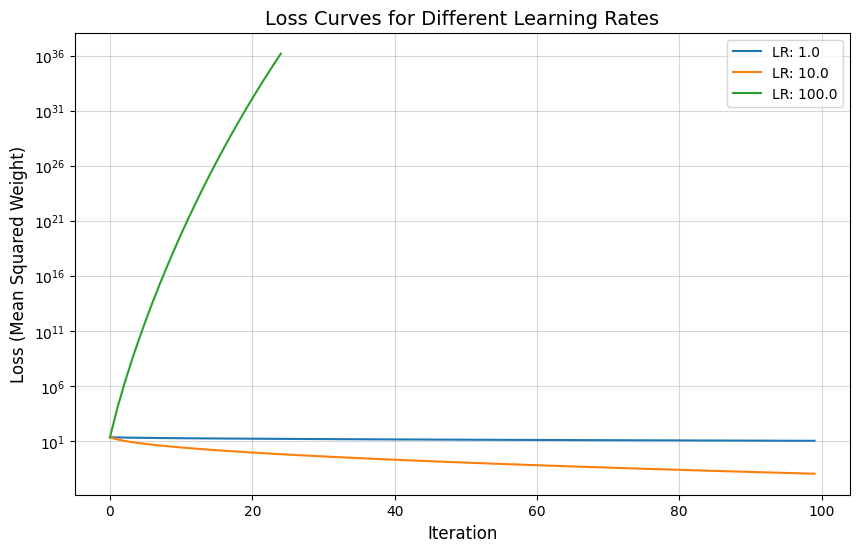

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for lr, losses in lr_results.items():    
    plt.plot(losses, label=f'LR: {lr}')

plt.title("Loss Curves for Different Learning Rates", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Loss (Mean Squared Weight)", fontsize=12)
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

## Problem (adamwAccounting): Resource accounting for training with AdamW

Let us compute how much memory and compute running AdamW requires. Assume we are using float32 for every tensor.

(a) How much peak memory does running AdamW require? Decompose your answer based on the memory usage of the parameters, activations, gradients, and optimizer state. Express your answer in terms of the `batch_size` and the model hyperparameters (`vocab_size`, `context_length`, `num_layers`, `d_model`, `num_heads`). Assume `d_ff = 4 × d_model`. For simplicity, when calculating memory usage of activations, consider only the following components:
- Transformer block
    - RMSNorm(s)
    - Multi-head self-attention sublayer: QKV projections, $Q^TK$ matrix multiply, softmax, weighted sum of values, output projection.
    - Position-wise feed-forward: W 1 matrix multiply, SiLU, W 2 matrix multiply
- final RMSNorm
- output embedding
- cross-entropy on logits

**Deliverable**: An algebraic expression for each of parameters, activations, gradients, and optimizer state, as well as the total.

Answer: the answer is given as follows (we assume using BF16 precision formats):

| component        | memory usage              |
| ---------------- | ------------------------- |
| weights          | $2P$                      |
| optimizer states | $12P$                     |
| gradients        | $2P$                      |
| activations      | $Lsb(32d+4hs) +( 4bsd+2bsV)$             |

where $P$ is the number of parameters, $b, s, d, L, V, h$ represents batch size, seq_len, d_model, num_layers, vocab_size and num_heads, respectively

(b) Instantiate your answer for a GPT-2 XL-shaped model to get an expression that only depends on the batch_size. What is the maximum batch size you can use and still fit within 80GB memory?

**Deliverable**: An expression that looks like a · batch_size + b for numerical values a, b, and a number representing the maximum batch size.

Answer: 7.659e9 * batch_size + 3.403e10, the maximum batch size is 6

In [63]:
def compute_memory(vocab_size, context_length, num_layers, d_model, num_heads, d_ff):
    num_parameters = compute_params(vocab_size, context_length, num_layers, d_model, num_heads, d_ff)
    a = num_layers * context_length * (32 * d_model + 4 * num_heads * context_length) + 4 * context_length * d_model + 2 * context_length * vocab_size
    b = 16 * num_parameters
    return a, b

a, b = compute_memory(50257, 1024, 48, 1600, 25, 6400)

print(f"expression: {a:.3e} * batch_size + {b:.3e}")

expression: 7.659e+09 * batch_size + 3.403e+10


In [64]:
import math

max_batch_size = math.floor((80 * 10**9 - b) / a)
max_batch_size

6

(c) How many FLOPs does running one step of AdamW take?

**Deliverable**: An algebraic expression, with a brief justification.

Answer: FLOPs is around 6 * P, for GPT-2 XL, this is about 1.28e+10 FLOPs/token

In [65]:
num_parameters = compute_params(50257, 1024, 48, 1600, 25, 6400)

print(f"parameters of GPT-2 XL: {num_parameters:.2e}")

print(f"FLOPs per token of GPT-2 XL: {6 * num_parameters: .2e}")

parameters of GPT-2 XL: 2.13e+09
FLOPs per token of GPT-2 XL:  1.28e+10


(d) Model FLOPs utilization (MFU) is defined as the ratio of observed throughput (tokens per second) relative to the hardware’s theoretical peak FLOP throughput [Chowdhery et al., 2022]. An NVIDIA A100 GPU has a theoretical peak of 19.5 teraFLOP/s for float32 operations. Assuming you are able to get 50% MFU, how long would it take to train a GPT-2 XL for 400K steps and a batch size of 1024 on a single A100? Following Kaplan et al. [2020] and Hoffmann et al. [2022], assume that the backward pass has twice the FLOPs of the forward pass.

**Deliverable**: The number of days training would take, with a brief justification.

Answer: 9559.67 hrs

In [66]:
# 312 TFLops for BF16 precision format
training_seconds = (1.28*10**10 * 400*10**3 * 1024 * 1024) / ( 312 * 10**12 * 0.5)
training_time = training_seconds / 60 / 60

print(f"training hours: {training_time:.2f} hrs")

training hours: 9559.67 hrs


# Experiments

Training configuration for baseline model

| field | value|
| --- | --- |
|vocab_size | 10000 |
|context_length | 256 |
|num_layers | 4|
|d_model | 512 |
|num_heads | 16 |
|d_ff | 1344 |
|lr | 1e-2 |
|batch size | 512 |
| weight decay | 0.1|
| adamW | (0.9, 0.95 ) |
| epoch | 1 |

In [1]:
num_params = compute_params(10000, 256, 4, 512, 16, 1344)

print(f"parameters of the trained model: {num_params / 10**9} B")

NameError: name 'compute_params' is not defined

## Problem (learning_rate): Tune the learning rate

The learning rate is one of the most important hyperparameters to tune. Taking the base model you’ve trained, answer the following questions:

(a) Perform a hyperparameter sweep over the learning rates and report the final losses (or note divergence if the optimizer diverges).

**Deliverable**: Learning curves associated with multiple learning rates. Explain your hyperparameter search strategy.

**Deliverable**: A model with validation loss (per-token) on TinyStories of at most 1.45

Answer: we train the models with learning curves of [0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001, 0.00001], the loss curve against the learning rate is given as

results show that: 
1. lr between [5e-4, 1e-2] attains a validation loss below 1.5
2. when lr is equal to 1e-2, the model attains the lowest validation loss with value 1.26

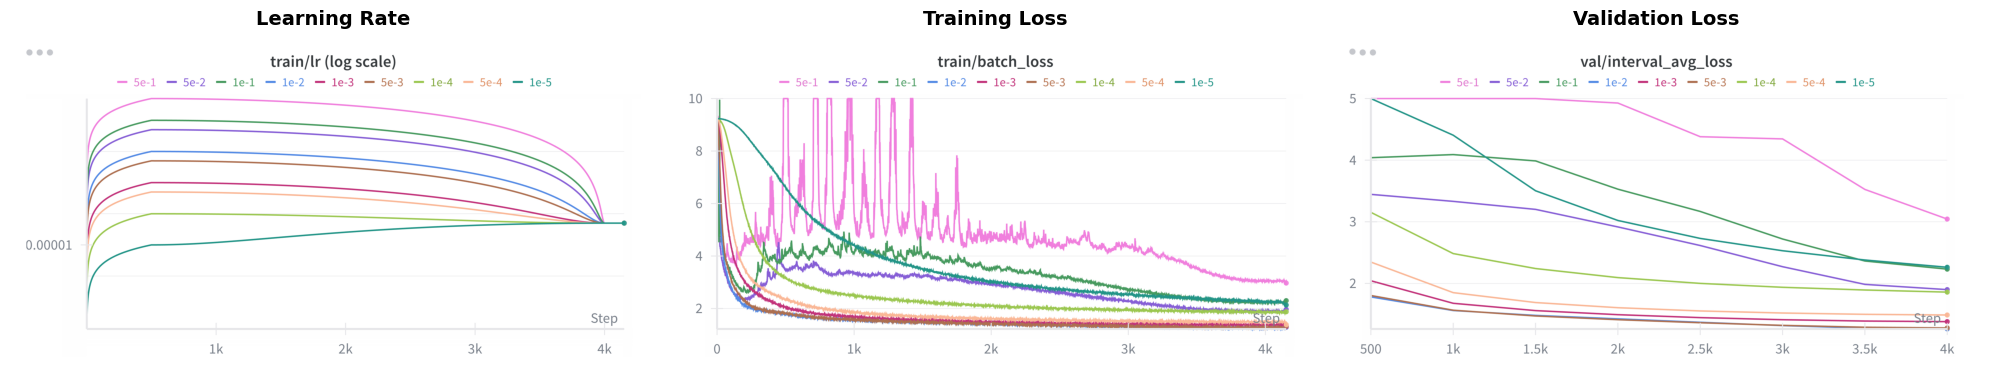

In [73]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load your three saved PNGs
img_lr = mpimg.imread('notebooks/lr_vs_steps.png')
img_train = mpimg.imread('notebooks/train_loss_vs_steps.png')
img_val = mpimg.imread('notebooks/val_loss_vs_steps.png')

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Define images and titles
images = [img_lr, img_train, img_val]
titles = ["Learning Rate", "Training Loss", "Validation Loss"]

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.axis('off')  # Hide pixel coordinates

plt.tight_layout()
plt.show()

(b) Folk wisdom is that the best learning rate is “at the edge of stability.” Investigate how the point at which learning rates diverge is related to your best learning rate.

**Deliverable**: Learning curves of increasing learning rate which include at least one divergent run and an analysis of how this relates to convergence rates.

Answer: when lr=1e-2, the model achieves the best performance, while lr=5e-5, the training becomes instable.

## Problem (batch_size_experiment): Batch size variations

Vary your batch size all the way from 1 to the GPU memory limit. Try at least a few batch sizes in between, including typical sizes like 64 and 128.

**Deliverable**: Learning curves for runs with different batch sizes. The learning rates should be optimized again if necessary.

**Deliverable**: A few sentences discussing of your findings on batch sizes and their impacts on training.

Answer: With larger batch size, the training is getting more stable, if the batch size is too small, the training becomes extremely slow and diverges.

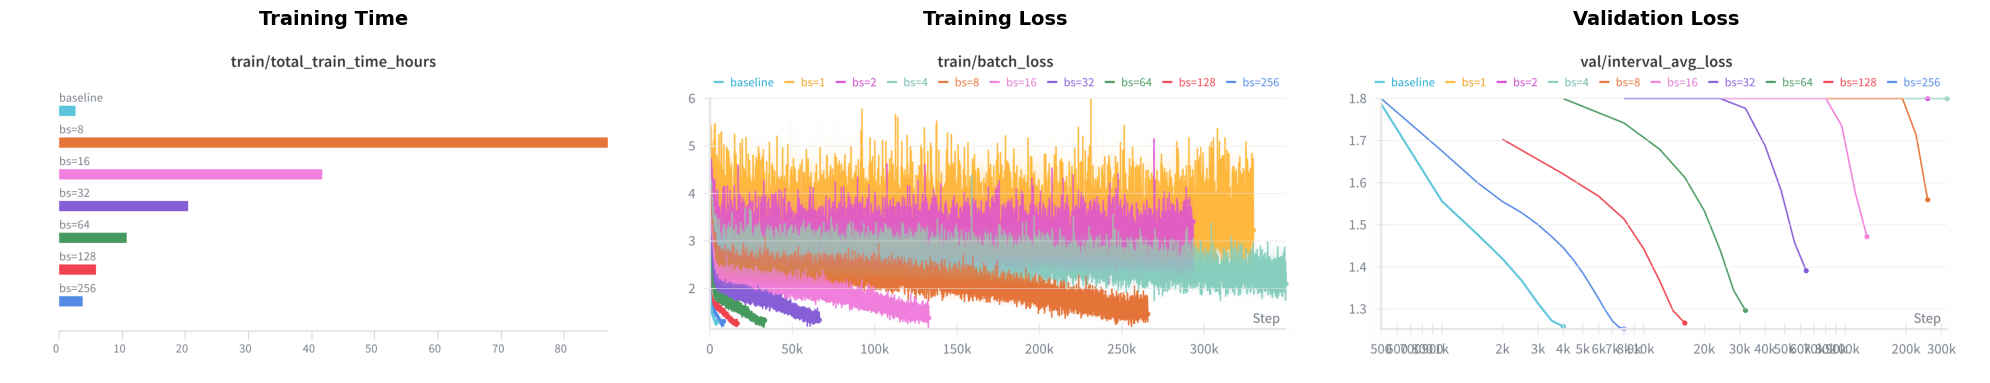

In [40]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load your three saved PNGs
img_time = mpimg.imread('notebooks/ablation-bs-training-time.png')
img_train = mpimg.imread('notebooks/ablation-bs-training.png')
img_val = mpimg.imread('notebooks/ablation-bs-validation.png')

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Define images and titles
images = [img_time, img_train, img_val]
titles = ["Training Time", "Training Loss", "Validation Loss"]

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.axis('off')  # Hide pixel coordinates

plt.tight_layout()
plt.show()

## Problem (generate): Generate text

Using your decoder and your trained checkpoint, report the text generated by your model. You may need to manipulate decoder parameters (temperature, top-p, etc.) to get fluent outputs.

**Deliverable**: Text dump of at least 256 tokens of text (or until the first <|endoftext|> token), and a brief comment on the fluency of this output and at least two factors which affect how good or bad this output is.

Answer: prompt `tell me a story`, the output is given as follows, it is not fluent and there is some repetition and conflicts, the model's capacity and the quality of dataset impact the output.

> ?"Lily was scared. She did not like Ben. She did not like his words. She did not want to talk to him."No, Ben, no," she said. "I don't want to hear your story. It is a bad story. It has bad people who want to take me away. They are mean and bad. They take me away. You are a bad boy. You have to give me your story."Ben felt angry. He did not like Lily's story. He did not like her words. He did not like her words. He did not want to be her friend. He did not want to give her his story. He wanted to go home."No, Lily, I don't want to give you my story. I want to sleep. You are not a bad friend. You are a bad girl. You don't share. I don't want to play with you," he said.Lily felt hurt. She did not want to play with Ben anymore. She wanted to go home. She wanted to stay with Ben. She wanted to play with her stories. She wanted to read them. She wanted to be happy. She wanted to sleep. She wanted to hug her mom. She wanted to sleep. She wanted to be alone. She wanted to go home. She wanted to read her story. She wanted to hug her mom. She wanted to hug her mom. She wanted to cry. She wanted to hear her mom. She

## Problem (layer_norm_ablation): Remove RMSNorm and train

Remove all of the RMSNorms from your Transformer and train. What happens at the previous optimal learning rate? Can you get stability by using a lower learning rate?

**Deliverable**: A learning curve for when you remove RMSNorms and train, as well as a learning curve for the best learning rate.

**Deliverable**: A few sentence commentary on the impact of RMSNorm.

Answer: After removing RMSNorm train the model with lr in $\{0.01, 0.001, 0.0001\}$, the result shows that if lr is too large, the training will diverge, by using a smaller lr, we can ensure convergence.

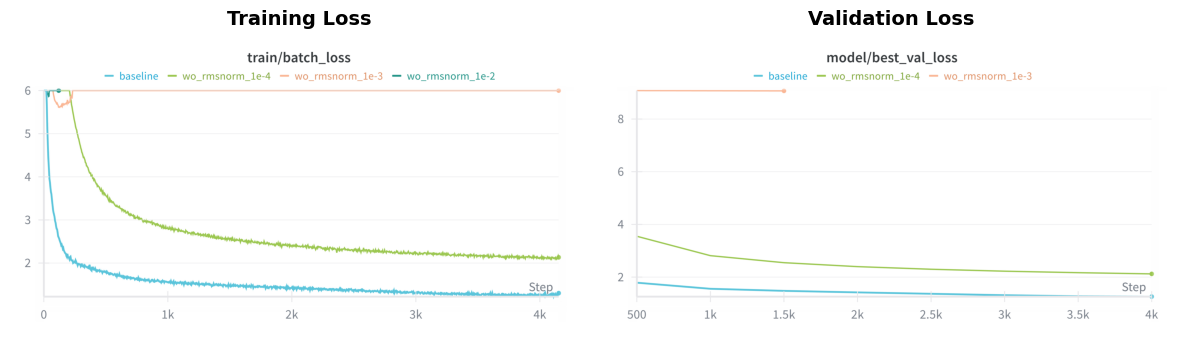

In [41]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load your three saved PNGs
img_train = mpimg.imread('notebooks/ablation-wo-norm-training.png')
img_val = mpimg.imread('notebooks/ablation-wo-norm-validation.png')

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Define images and titles
images = [img_train, img_val]
titles = ["Training Loss", "Validation Loss"]

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.axis('off')  # Hide pixel coordinates

plt.tight_layout()
plt.show()

## Problem (pre_norm_ablation): Implement post-norm and train

Modify your pre-norm Transformer implementation into a post-norm one. Train with the post-norm model and see what happens.

**Deliverable**: A learning curve for a post-norm transformer, compared to the pre-norm one.

Answer: the pre-norm performs better than post-norm

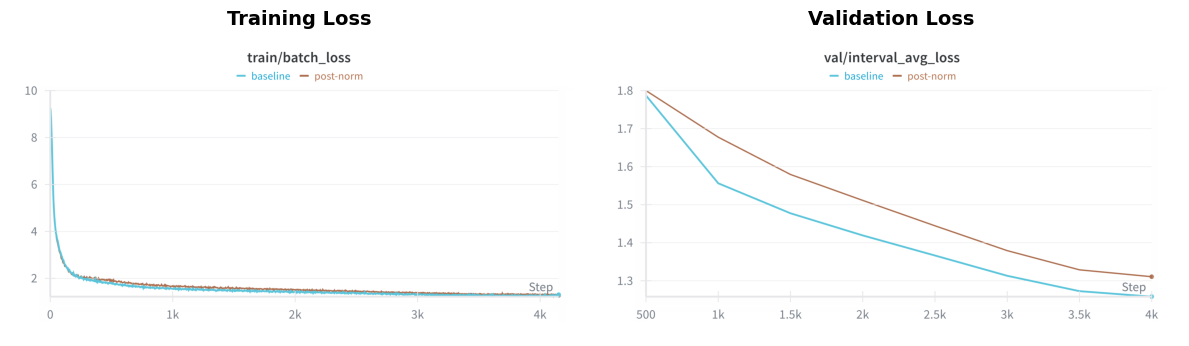

In [34]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load your three saved PNGs
img_train = mpimg.imread('notebooks/ablation-norm-position-training.png')
img_val = mpimg.imread('notebooks/ablation-norm-position-validation.png')

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Define images and titles
images = [img_train, img_val]
titles = ["Training Loss", "Validation Loss"]

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.axis('off')  # Hide pixel coordinates

plt.tight_layout()
plt.show()

## Problem (no_pos_emb): Implement NoPE

Modify your Transformer implementation with RoPE to remove the position embedding information entirely, and see what happens.

**Deliverable**: A learning curve comparing the performance of RoPE and NoPE.

Answer: With same configuration (expect one with no RopE), the performance of NoPE is worse than RoPE

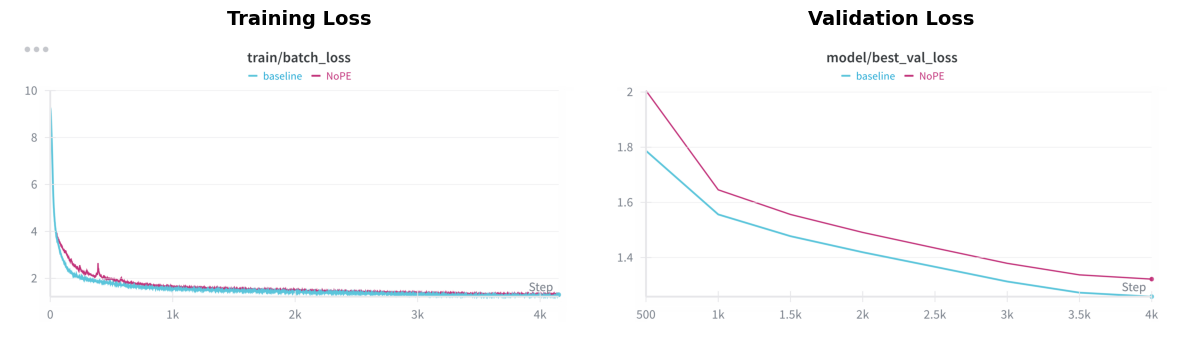

In [32]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load your three saved PNGs
img_train = mpimg.imread('notebooks/ablation-NoPE-training.png')
img_val = mpimg.imread('notebooks/ablation-NoPE-validation.png')

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Define images and titles
images = [img_train, img_val]
titles = ["Training Loss", "Validation Loss"]

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.axis('off')  # Hide pixel coordinates

plt.tight_layout()
plt.show()

## Problem (swiglu_ablation): SwiGLU vs. SiLU

**Deliverable**: A learning curve comparing the performance of SwiGLU and SiLU feed-forward networks, with approximately matched parameter counts.

**Deliverable**: A few sentences discussing your findings.

Answer: The SiLU FFN is slightly worse than SwiGLU

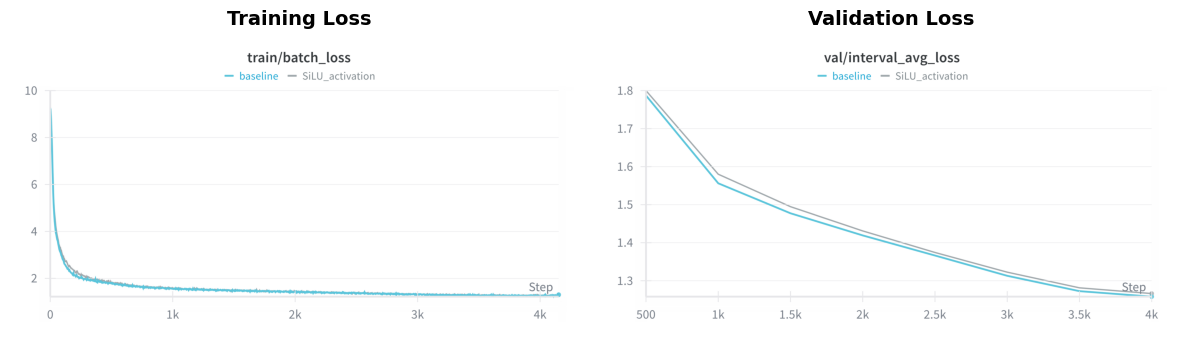

In [33]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load your three saved PNGs
img_train = mpimg.imread('notebooks/ablation-FFN-training.png')
img_val = mpimg.imread('notebooks/ablation-FFN-validation.png')

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Define images and titles
images = [img_train, img_val]
titles = ["Training Loss", "Validation Loss"]

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.axis('off')  # Hide pixel coordinates

plt.tight_layout()
plt.show()

## Problem (main_experiment): Experiment on OWT

Train your language model on OpenWebText with the same model architecture and total training iterations as TinyStories. How well does this model do?

**Deliverable**: A learning curve of your language model on OpenWebText. Describe the difference in losses from TinyStories – how should we interpret these losses?

**Deliverable**: Generated text from OpenWebText LM, in the same format as the TinyStories outputs. How is the fluency of this text? Why is the output quality worse even though we have the same model and compute budget as TinyStories?

Answer: 1. the training loss of the model on OWT dataset is higher than the TinyStories dataset.

2. the output corresponding to the prompt `once upon a time`, the quality is lower since the dataset becomes more diverse and the vocabulary is larger and the model is under fit.
```
once upon a time, there was a little girl named Sue. She had a pretty dress that she loved very much. One day, she went to the park to play with her friends.While playing, Sue saw a boy named Tim. Tim had a toy that looked like a car. Sue felt envious because she wanted a car like that too. She asked Tim, "Can I play with your car?"Tim said, "Yes, but be careful. It's my favorite toy." Sue was very happy and played
```

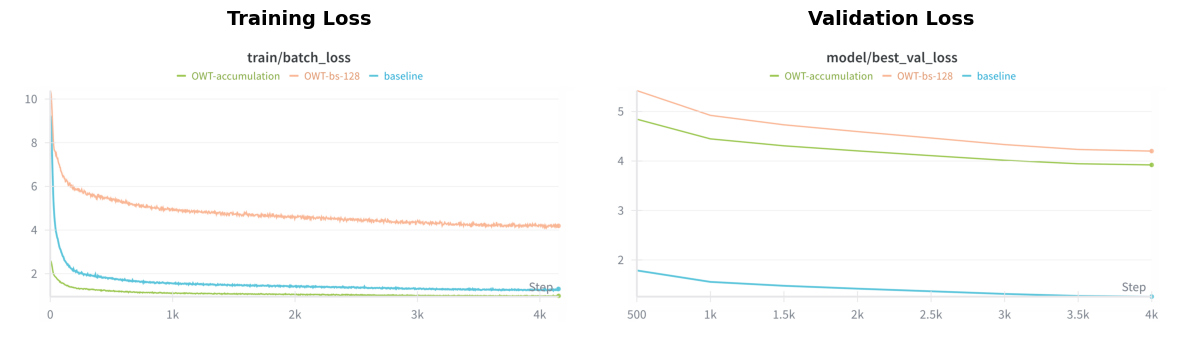

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load your three saved PNGs
img_train = mpimg.imread('notebooks/OWT_training_loss_curve.png')
img_val = mpimg.imread('notebooks/OWT_validation_loss.png')

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Define images and titles
images = [img_train, img_val]
titles = ["Training Loss", "Validation Loss"]

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.axis('off')  # Hide pixel coordinates

plt.tight_layout()
plt.show()

## Problem (leaderboard): Leaderboard

You will train a model under the leaderboard rules above with the goal of minimizing the validation loss of your language model within 1.5 H100-hour.

**Deliverable**: The final validation loss that was recorded, an associated learning curve that clearly shows a wallclock-time x-axis that is less than 1.5 hours and a description of what you did. We expect a leaderboard submission to beat at least the naive baseline of a 5.0 loss. Submit to the leaderboard here: https://github.com/stanford-cs336/assignment1-basics-leaderboard.